<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# Classification and KNN with NHL data

_Authors: Joseph Nelson (DC)_

---

Below you will practice KNN classification on a dataset of NHL statistics.

You will be predicting the `Rank` of a team from predictor variables of your choice.

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt



import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# web location:
local_csv = 'data/NHL_Data_GA.csv'

### 1. Load the NHL data

In [3]:
df = pd.read_csv(local_csv)

### 2. Perform any required data cleaning. Do some EDA.

In [10]:
pd.set_option('display.max_columns', None)
df.head()

,Team,PTS,Rank,TOI,GF,GA,GF60,GA60,GF%,SF,SA,SF60,SA60,SF%,FF,FA,FF60,FA60,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
0,Washington10,121,1,2001:52:00,115,73,3.45,2.19,61.2,1112,1047,33.3,31.4,51.5,1526,1449,45.7,43.4,51.3,2138,1935,64.1,58.0,52.5,10.34,93.03,1034,1269
1,Vancouver11,117,1,2056:14:00,94,72,2.74,2.10,56.6,1143,1053,33.4,30.7,52.0,1602,1414,46.7,41.3,53.1,2144,1870,62.6,54.6,53.4,8.22,93.16,1014,985
2,San Jose10,113,1,1929:54:00,90,68,2.80,2.11,57.0,1065,1039,33.1,32.3,50.6,1493,1442,46.4,44.8,50.9,1985,1876,61.7,58.3,51.4,8.45,93.46,1019,1195
3,Chicago10,112,1,2020:23:00,104,83,3.09,2.46,55.6,1186,868,35.2,25.8,57.7,1599,1151,47.5,34.2,58.1,2093,1572,62.2,46.7,57.1,8.77,90.44,992,966
4,Vancouver12,111,1,2052:02:00,86,74,2.51,2.16,53.8,1078,1115,31.5,32.6,49.2,1504,1442,44.0,42.2,51.0,2085,1880,61.0,55.0,52.6,7.98,93.36,1013,1049


In [4]:
# A:
pd.set_option('display.max_columns', None)
df.describe()


,PTS,Rank,GF,GA,GF60,GA60,GF%,SF,SA,SF60,SA60,SF%,FF,FA,FF60,FA60,FF%,CF,CA,CF60,CA60,CF%,Sh%,Sv%,PDO,PIM
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,91.977778,2.022222,83.288889,83.288889,2.442222,2.444000,49.981111,1068.333333,1068.333333,31.252222,31.292222,49.956667,1475.377778,1475.377778,43.155556,43.217778,49.966667,1973.466667,1973.466667,57.735556,57.798889,49.972222,7.814556,92.182556,999.988889,990.966667
std,12.524114,0.820767,10.376339,9.694484,0.325331,0.313522,4.644554,95.929047,75.514118,2.237637,2.100306,2.793494,129.880116,109.025569,2.951180,3.047105,2.797913,176.468299,154.148928,4.124476,4.291106,2.844313,0.866942,0.928621,12.292772,178.049321
min,62.000000,1.000000,57.000000,64.000000,1.700000,1.730000,38.000000,815.000000,868.000000,25.800000,25.800000,43.200000,1138.000000,1151.000000,36.000000,34.200000,43.100000,1565.000000,1572.000000,49.500000,46.700000,43.700000,5.900000,89.830000,978.000000,689.000000
25%,82.250000,1.000000,76.000000,75.500000,2.232500,2.202500,46.825000,1011.500000,1022.250000,29.550000,29.800000,48.300000,1380.750000,1409.500000,40.900000,41.350000,47.775000,1855.250000,1877.000000,54.275000,54.600000,47.925000,7.235000,91.555000,992.000000,881.250000
50%,92.500000,2.000000,84.000000,84.000000,2.400000,2.495000,49.700000,1072.000000,1072.000000,31.400000,31.500000,50.150000,1474.500000,1477.500000,43.400000,43.450000,50.050000,1981.500000,1961.000000,58.050000,58.350000,50.400000,7.730000,92.250000,1000.500000,960.000000
75%,102.000000,3.000000,90.000000,89.000000,2.600000,2.670000,53.625000,1143.000000,1125.750000,32.775000,32.900000,51.675000,1566.250000,1551.000000,45.500000,45.150000,51.775000,2112.750000,2077.250000,60.850000,60.400000,52.000000,8.270000,92.870000,1007.750000,1101.500000
max,121.000000,3.000000,115.000000,107.000000,3.450000,3.240000,61.200000,1311.000000,1245.000000,35.600000,35.900000,57.700000,1762.000000,1735.000000,49.500000,50.500000,58.100000,2341.000000,2332.000000,64.900000,67.500000,57.100000,10.340000,93.940000,1034.000000,1515.000000


In [5]:
df.columns

Index(['Team', 'PTS', 'Rank', 'TOI', 'GF', 'GA', 'GF60', 'GA60', 'GF%', 'SF',
       'SA', 'SF60', 'SA60', 'SF%', 'FF', 'FA', 'FF60', 'FA60', 'FF%', 'CF',
       'CA', 'CF60', 'CA60', 'CF%', 'Sh%', 'Sv%', 'PDO', 'PIM'],
      dtype='str')

In [8]:
df.dtypes

Team        str
PTS       int64
Rank      int64
TOI         str
GF        int64
GA        int64
GF60    float64
GA60    float64
GF%     float64
SF        int64
SA        int64
SF60    float64
SA60    float64
SF%     float64
FF        int64
FA        int64
FF60    float64
FA60    float64
FF%     float64
CF        int64
CA        int64
CF60    float64
CA60    float64
CF%     float64
Sh%     float64
Sv%     float64
PDO       int64
PIM       int64
dtype: object

In [11]:
toi = pd.to_timedelta(df["TOI"])

df["TOI_minutes"] = toi.dt.total_seconds() / 60



### 3. Set up the `Rank` variable as your target. How many classes are there?

In [13]:
# A:
y = df["Rank"]

print("Number of classes:", len(y.unique()))

Number of classes: 3


### 4. What is the baseline accuracy?

In [20]:
# A: 
X= df.drop('Rank',axis=1)
y= df['Rank']
print(df['Rank'].value_counts()/len(df))

X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.20, stratify=y,random_state=99)
y_train.value_counts()/len(y_train) , y_test.value_counts()/len(y_test)

y

Rank
3    0.344444
2    0.333333
1    0.322222
Name: count, dtype: float64


(Rank
 3    0.347222
 2    0.333333
 1    0.319444
 Name: count, dtype: float64,
 Rank
 1    0.333333
 2    0.333333
 3    0.333333
 Name: count, dtype: float64)

### 5. Choose 4 features to be your predictor variables and set up your design matrix.

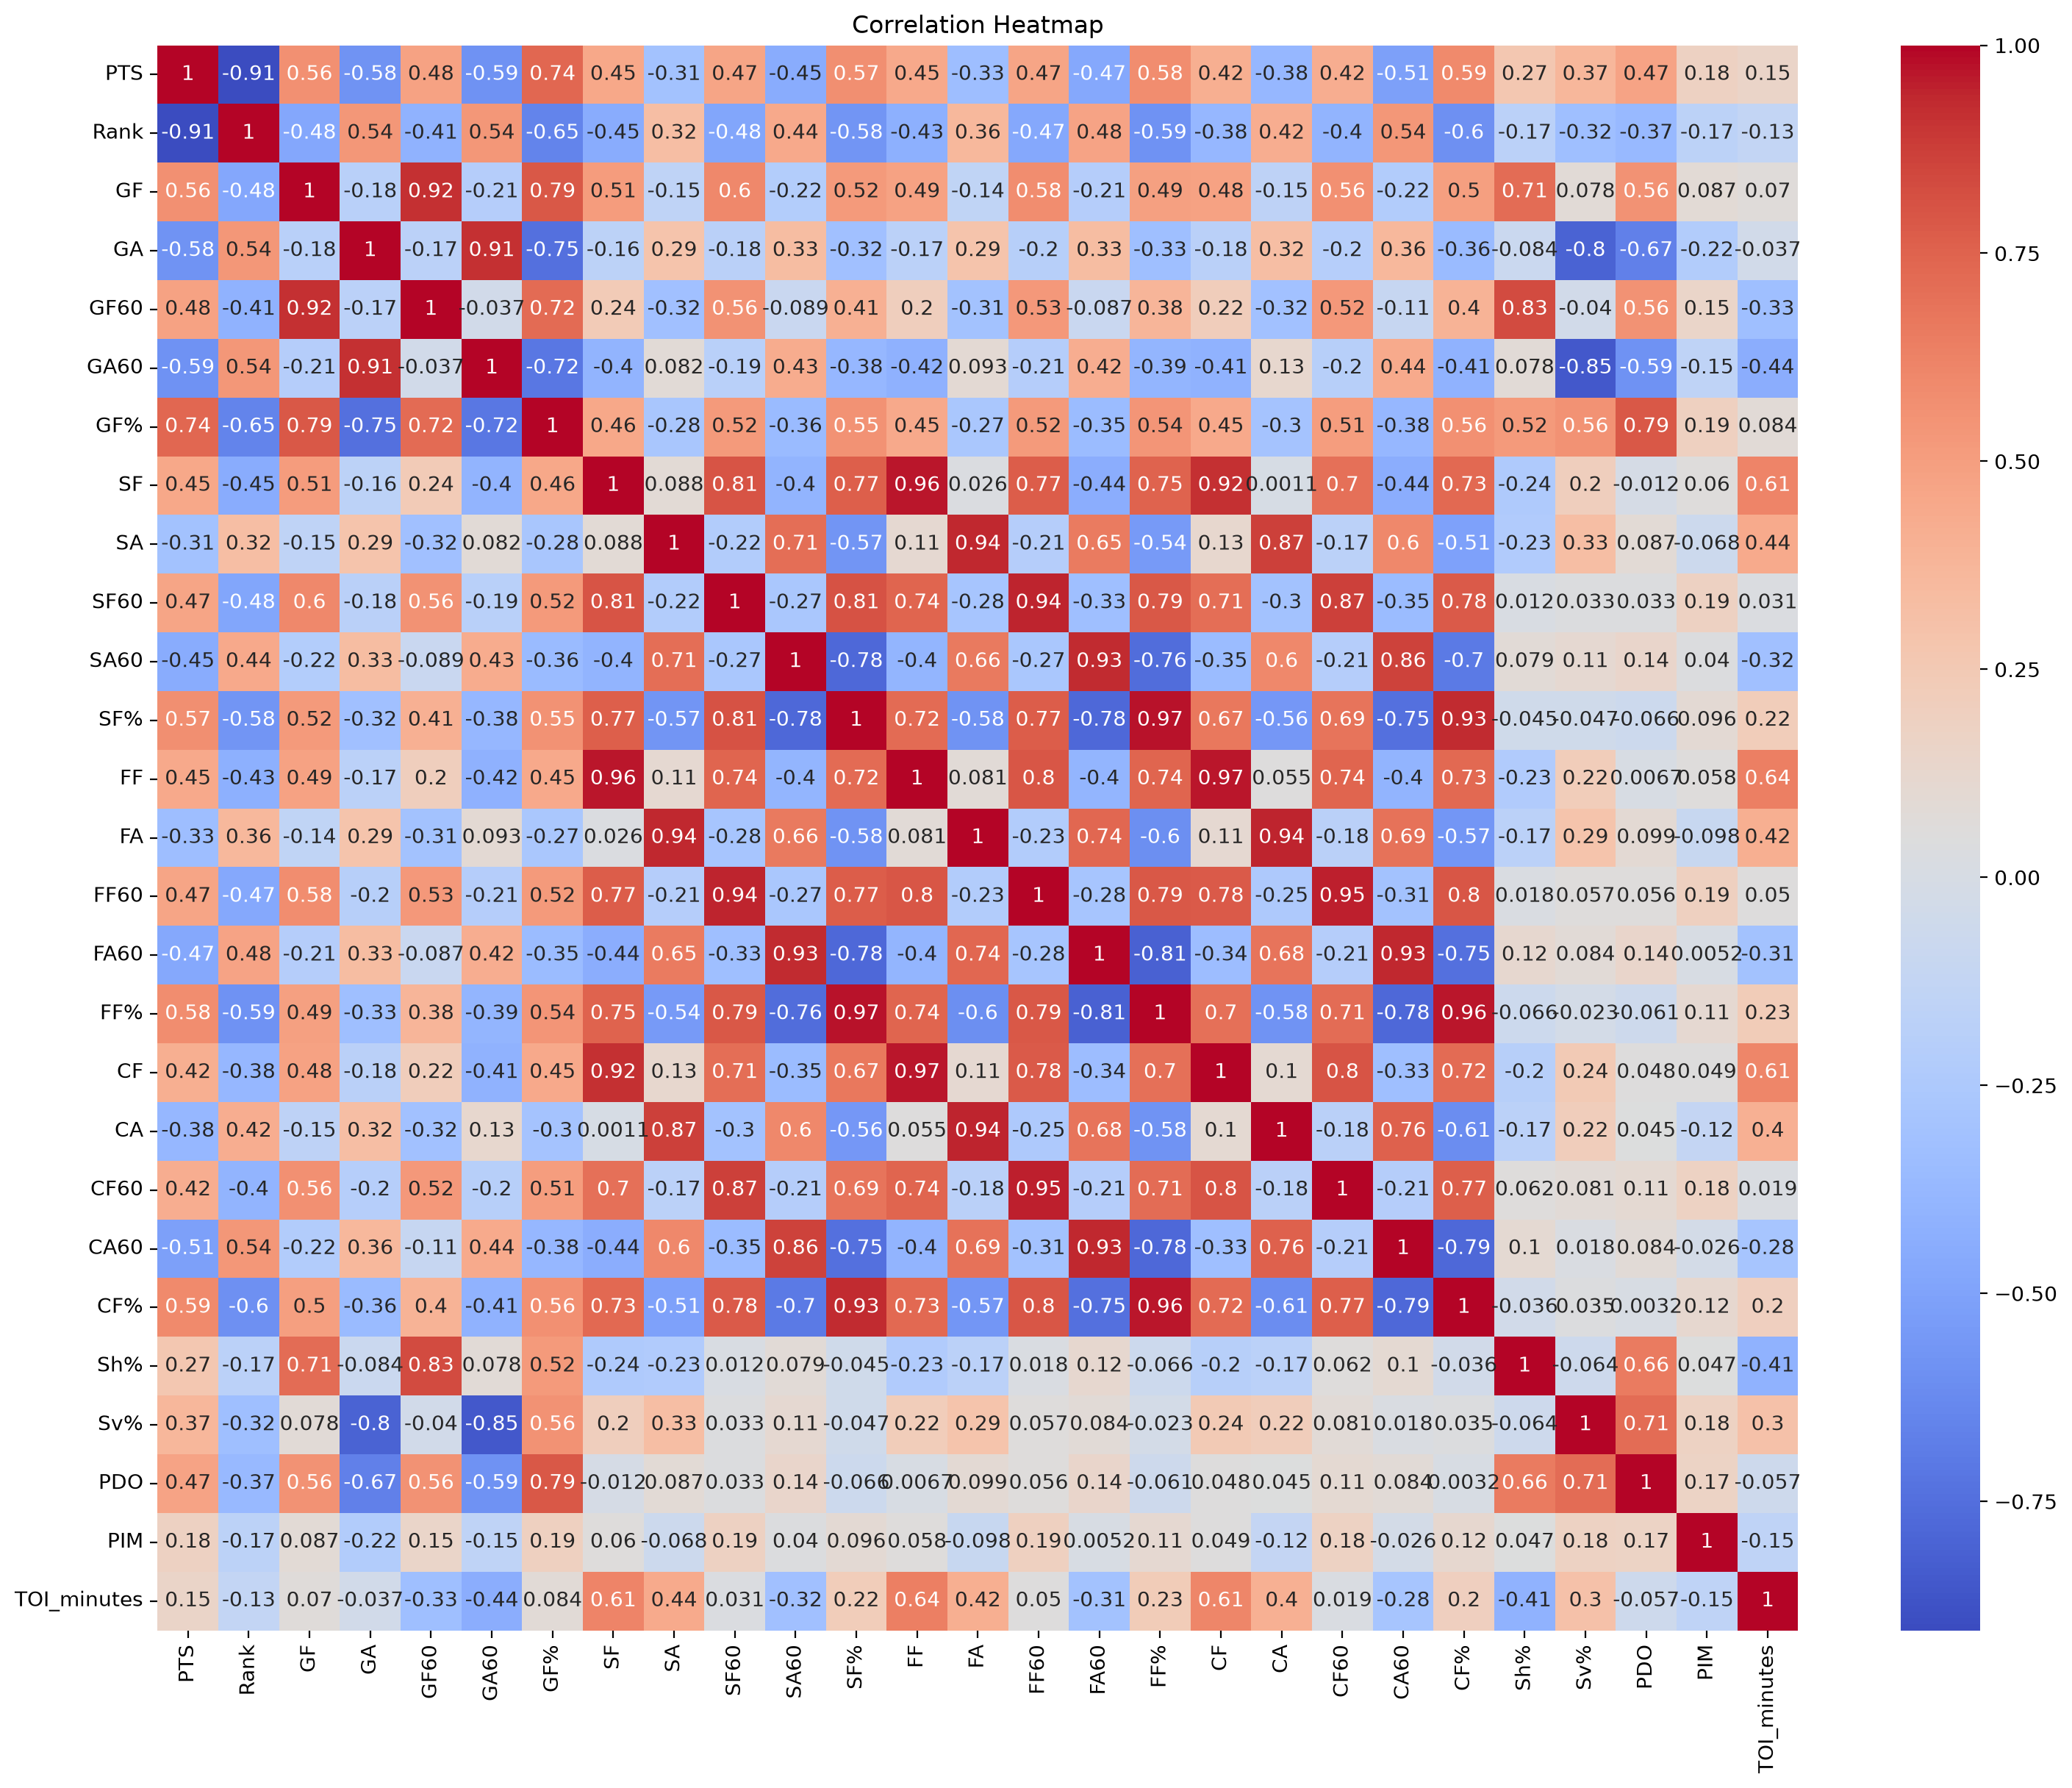

In [21]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
# A:
X= df[['PTS','GF%','CF%']]
y= df['Rank']

X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.20, stratify=y,random_state=99)


### 6. Fit a `KNeighborsClassifier` with 1 neighbor using the target and predictors.

In [26]:
# A:
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 7. Evaluate the accuracy of your model.
- Is it better than baseline?
- Is it legitimate?

In [28]:
knn.score(X_train, y_train)

0.9861111111111112

In [27]:
# A:
knn.score(X_test, y_test)

0.9444444444444444

- Is it better than baseline? Yes
- Is it legitimate? Yes

### 8. Create a 50-50 train-test-split of your target and predictors. Refit the KNN and assess the accuracy.

In [29]:
# A:
X_train,X_test, y_train,y_test = train_test_split(X,y, test_size=0.50, stratify=y,random_state=99)


knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

knn.score(X_test, y_test)

0.9333333333333333

### 9. Evaluate the test accuracy of a KNN where K == number of rows in the training data.

In [30]:
# A:

k = len(X_train)

knn = KNeighborsClassifier(n_neighbors=k)

knn.fit(X_train, y_train)

print(knn.score(X_test, y_test))

0.3111111111111111


### 10. Fit the KNN at values of K from 1 to the number of rows in the training data.
- Store the test accuracy in a list.
- Plot the test accuracy vs. the number of neighbors.

In [31]:
# A:
max_k = X_train.shape[0]

k_values = range(1, max_k + 1)

test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    accuracy = knn.score(X_test, y_test)

    test_accuracies.append(accuracy)



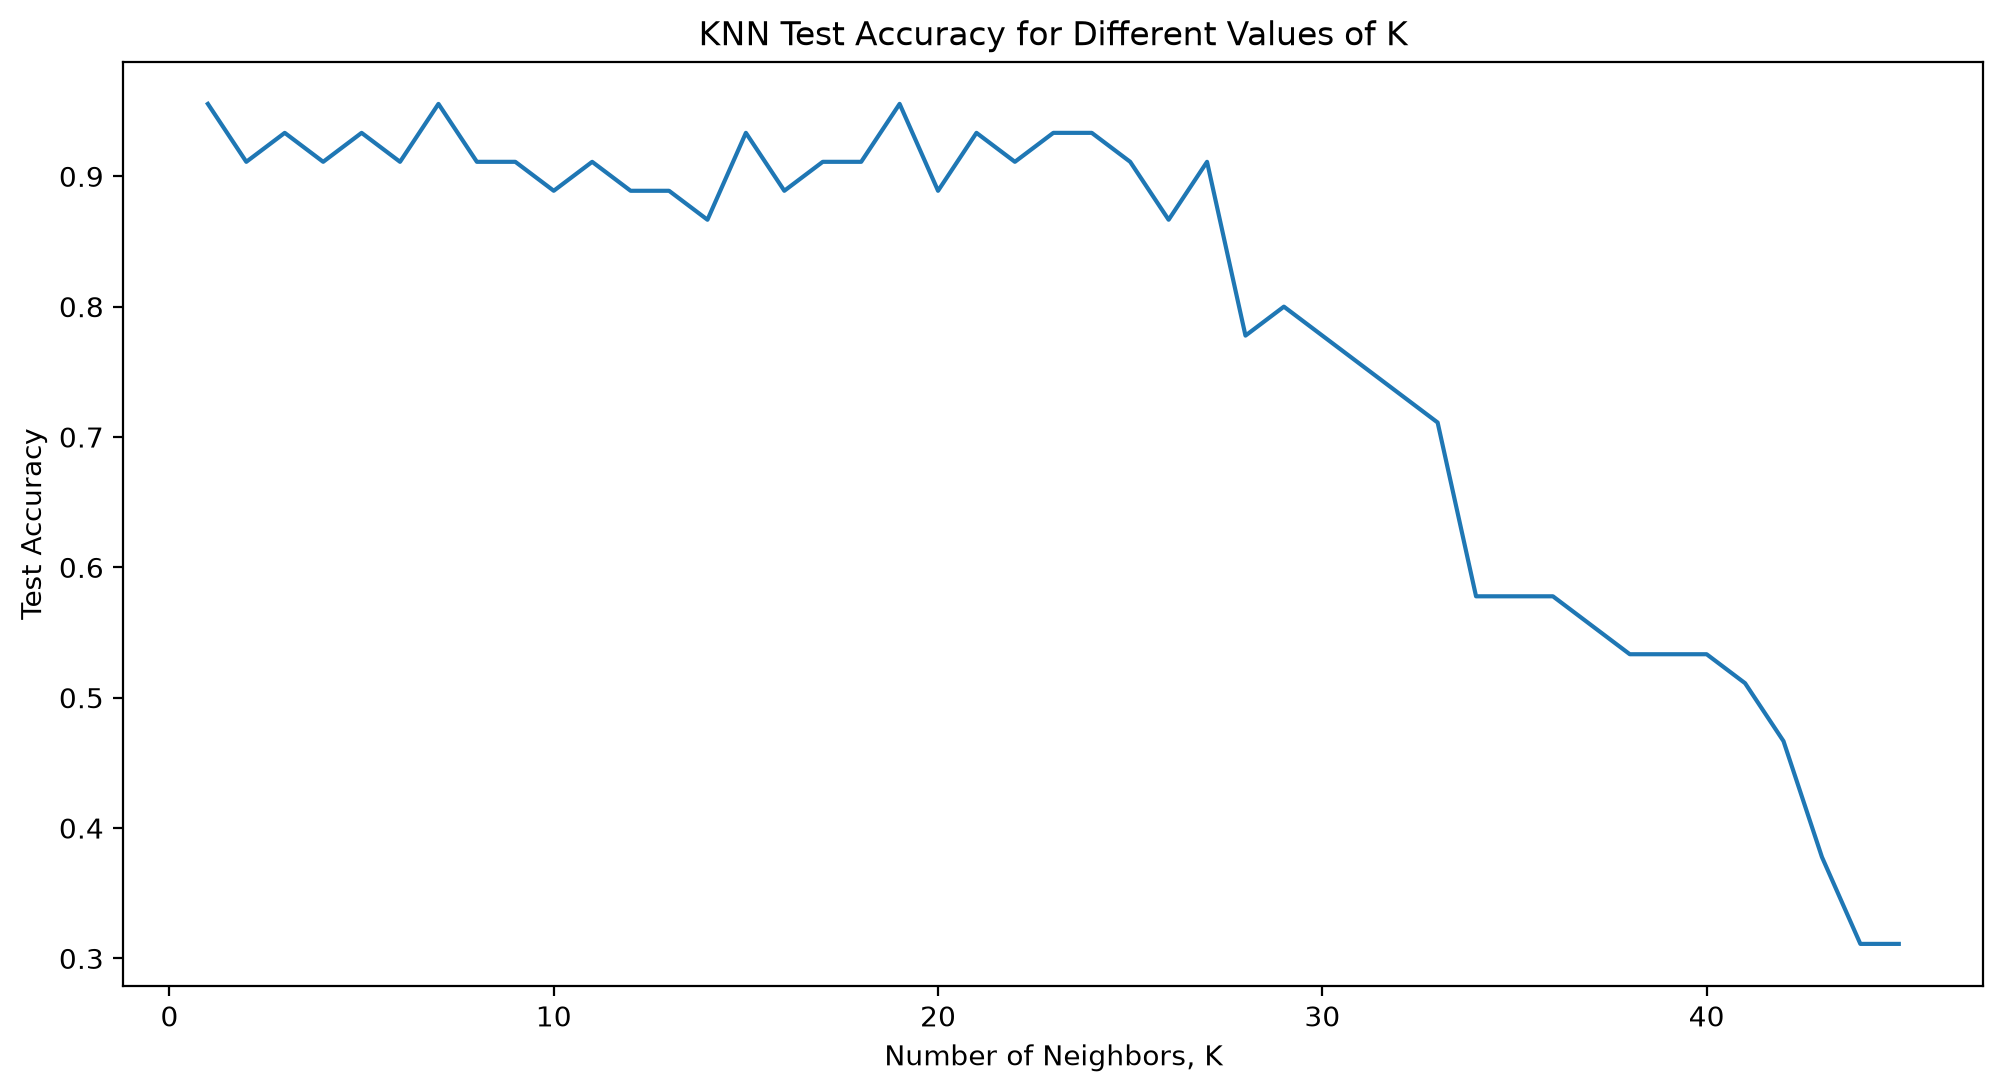

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(k_values, test_accuracies)

plt.xlabel("Number of Neighbors, K")
plt.ylabel("Test Accuracy")
plt.title("KNN Test Accuracy for Different Values of K")

plt.show()

### 11. Fit KNN across different values of K and plot the mean cross-validated accuracy with 5 folds.

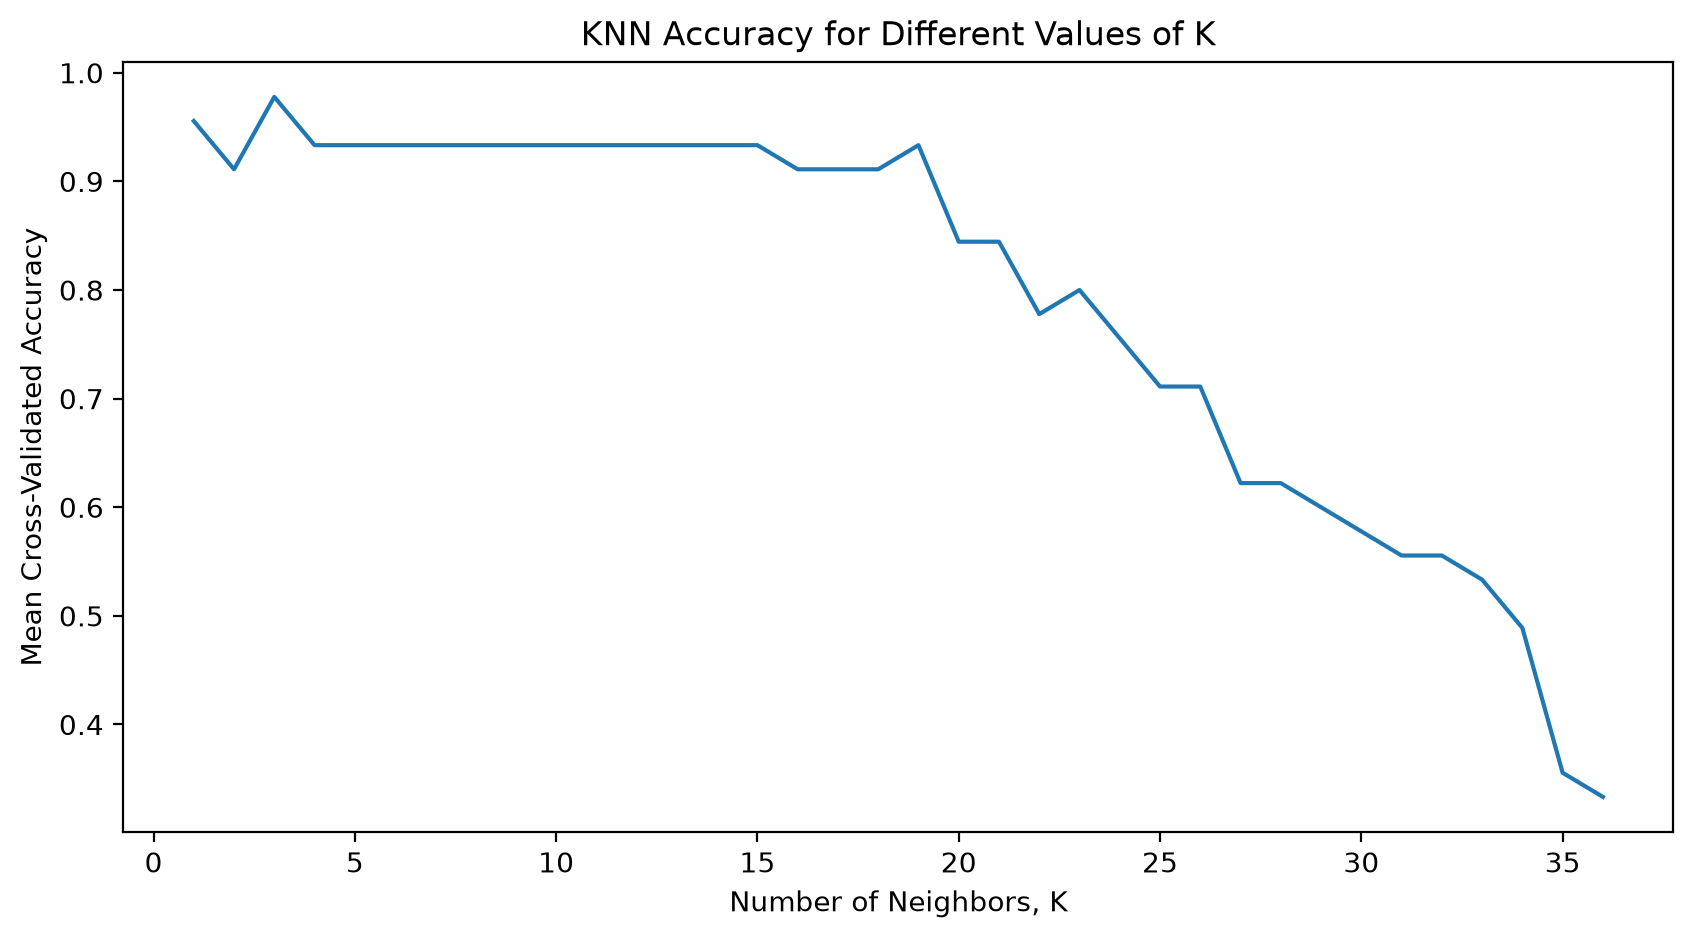

In [44]:
# A:
cv_mean_accuracies = []
max_k = int(len(X_train) * 0.8)

k_values = range(1, max_k + 1)

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring="accuracy")
    cv_mean_accuracies.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_mean_accuracies)

plt.xlabel("Number of Neighbors, K")
plt.ylabel("Mean Cross-Validated Accuracy")
plt.title("KNN Accuracy for Different Values of K")

plt.show()


In [55]:
cv_mean_accuracies.sort(reverse=True)
cv_mean_accuracies

[np.float64(0.9777777777777779),
 np.float64(0.9555555555555555),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9333333333333332),
 np.float64(0.9111111111111111),
 np.float64(0.9111111111111111),
 np.float64(0.9111111111111111),
 np.float64(0.9111111111111111),
 np.float64(0.8444444444444444),
 np.float64(0.8444444444444444),
 np.float64(0.7999999999999999),
 np.float64(0.7777777777777777),
 np.float64(0.7555555555555555),
 np.float64(0.711111111111111),
 np.float64(0.711111111111111),
 np.float64(0.6222222222222221),
 np.float64(0.6222222222222221),
 np.float64(0.6),
 np.float64(0.5777777777777778),
 np.float64(0.5555555555555

### 12. Standardize the predictor matrix and cross-validate across the different K.
- Plot the standardized mean cross-validated accuracy against the unstandardized. Which is better?
- Why?

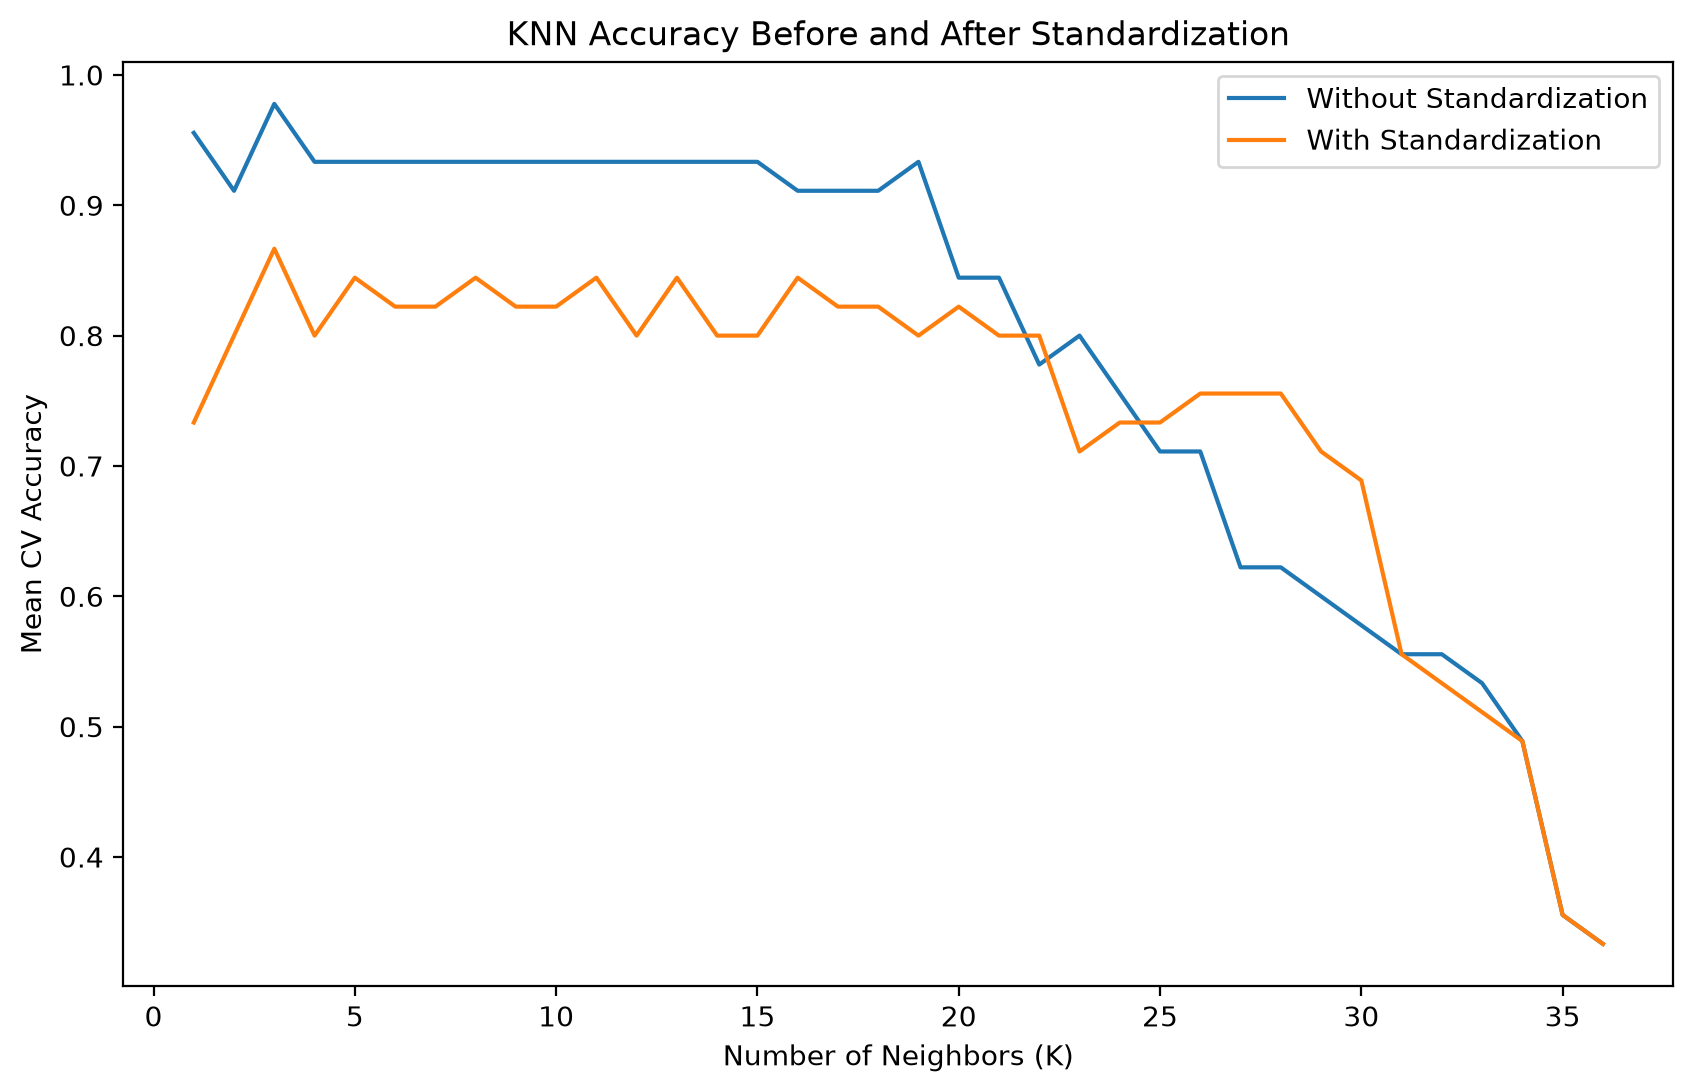

In [49]:
# A:

# Use the same K values as Question 11
max_k = int(len(X_train) * 0.8)
k_values = range(1, max_k + 1)

scaled_cv_accuracies = []

for k in k_values:

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    scaled_cv_accuracies.append(scores.mean())


plt.figure(figsize=(10,6))

plt.plot(k_values, cv_mean_accuracies,
         label="Without Standardization")

plt.plot(k_values, scaled_cv_accuracies,
         label="With Standardization")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean CV Accuracy")
plt.title("KNN Accuracy Before and After Standardization")
plt.legend()

plt.show()

In [51]:
print("Best accuracy without scaling:", max(cv_mean_accuracies))
print("Best K without scaling:", k_values[np.argmax(cv_mean_accuracies)])

print("Best accuracy with scaling:", max(scaled_cv_accuracies))
print("Best K with scaling:", k_values[np.argmax(scaled_cv_accuracies)])

Best accuracy without scaling: 0.9777777777777779
Best K without scaling: 3
Best accuracy with scaling: 0.8666666666666666
Best K with scaling: 3


## What was the best 'k'?

Using `GridSearch` & `Pipeline` find the best `k` for the KNN model

- #### The best K is 3 because it produced the highest cross-validation accuracy. It provides a good balance between overfitting and underfitting, allowing the model to generalize better to unseen data.